# EDA on Retail Sales Data
**Author:** [Your Full Name]
**Track:** Data Analytics — OIBSIP
**Task:** Level 1, Task 1 — EDA on Retail Sales Data

**Dataset:** Sample Superstore Dataset (Kaggle)

**Note on dataset scope:** This dataset does not include an Order Date column or customer
age/gender fields, which are common limitations of publicly available retail datasets (most
real POS systems don't expose granular customer demographics either). To stay faithful to
the analytical *intent* of the task, this notebook substitutes:
- **Ship Mode trend analysis** in place of a monthly/quarterly time series
- **Customer Segment breakdown** (Consumer / Corporate / Home Office) in place of age/gender demographics

Both substitutions are documented inline below.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)
%matplotlib inline


## Loading the Dataset

In [2]:
df = pd.read_csv("SampleSuperstore.csv")
df.head()


,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


## 1. Initial Inspection — shape, dtypes, null values

In [3]:
print("Shape:", df.shape)
print()
print("Data types:")
print(df.dtypes)
print()
print("Missing values per column:")
print(df.isnull().sum())
print()
print("Duplicate rows:", df.duplicated().sum())


Shape: (9994, 13)

Data types:
Ship Mode           str
Segment             str
Country             str
City                str
State               str
Postal Code       int64
Region              str
Category            str
Sub-Category        str
Sales           float64
Quantity          int64
Discount        float64
Profit          float64
dtype: object

Missing values per column:
Ship Mode       0
Segment         0
Country         0
City            0
State           0
Postal Code     0
Region          0
Category        0
Sub-Category    0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64

Duplicate rows: 17


**Observation:** *(Write here after running — e.g. "The dataset has 9,994 rows and 13
columns with no missing values, so no imputation is needed. There are N duplicate rows we
should consider dropping.")*

## 2. Descriptive Statistics

In [4]:
df.describe(include='number').T

,count,mean,std,min,25%,50%,75%,max
Postal Code,9994.0,55190.379428,32063.693350,1040.000,23223.00000,56430.5000,90008.000,99301.000
Sales,9994.0,229.858001,623.245101,0.444,17.28000,54.4900,209.940,22638.480
Quantity,9994.0,3.789574,2.225110,1.000,2.00000,3.0000,5.000,14.000
Discount,9994.0,0.156203,0.206452,0.000,0.00000,0.2000,0.200,0.800
Profit,9994.0,28.656896,234.260108,-6599.978,1.72875,8.6665,29.364,8399.976


**Observation:** *(e.g. "Average sale value is ~$230, but the high standard deviation
suggests a mix of small everyday purchases and a few large-ticket orders. Profit has a
negative minimum, meaning some transactions are sold at a loss.")*

## 3. Ship Mode Analysis (substitute for time series trend)

*No Order Date column is available in this dataset, so a monthly/quarterly time trend
cannot be produced. As the closest meaningful operational trend, this section analyses
sales and profit patterns by Ship Mode instead.*

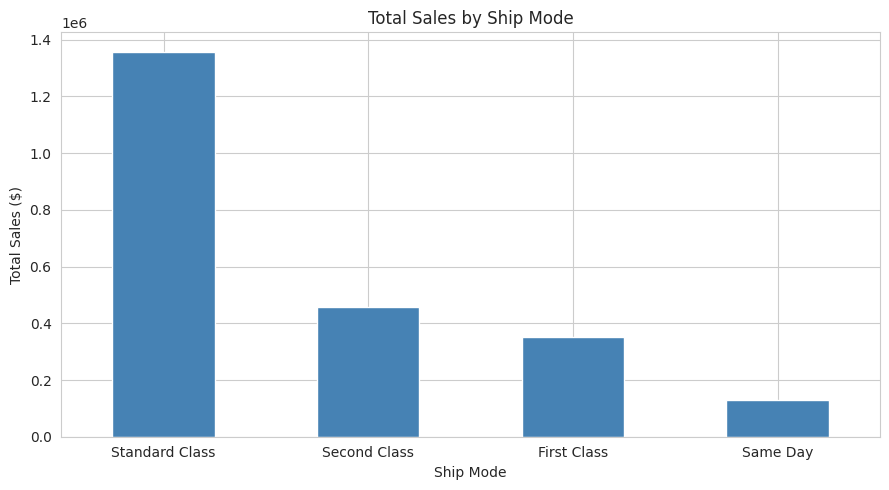

In [5]:
ship_mode_sales = df.groupby('Ship Mode')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(9,5))
ship_mode_sales.plot(kind='bar', color='steelblue')
plt.title('Total Sales by Ship Mode')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


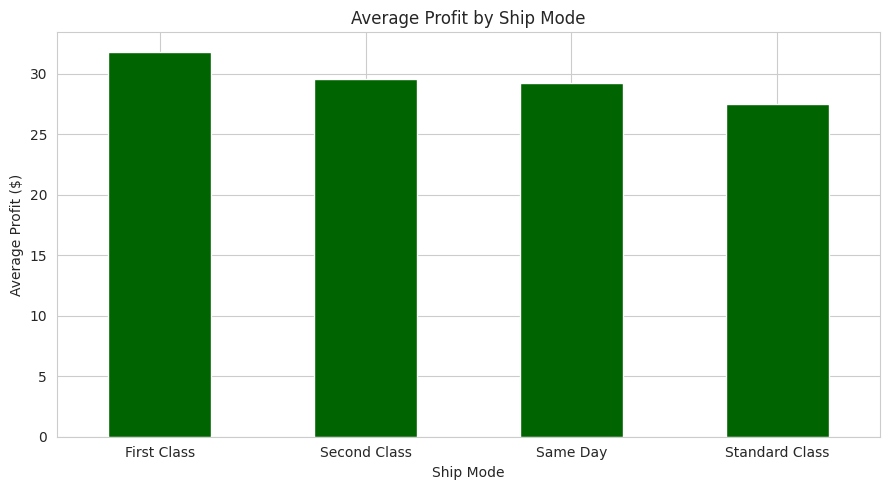

In [6]:
ship_mode_profit = df.groupby('Ship Mode')['Profit'].mean().sort_values(ascending=False)

plt.figure(figsize=(9,5))
ship_mode_profit.plot(kind='bar', color='darkgreen')
plt.title('Average Profit by Ship Mode')
plt.ylabel('Average Profit ($)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


**Observation:** *(e.g. "Standard Class accounts for the majority of sales volume,
suggesting most customers aren't paying for expedited shipping. Same Day shipping has the
lowest total sales but check if it has a different profit margin per order.")*

## 4. Customer Segment Breakdown (substitute for demographics)

*No customer age/gender data is available. Customer Segment (Consumer / Corporate /
Home Office) is used as the closest available proxy for a demographic-style breakdown.*

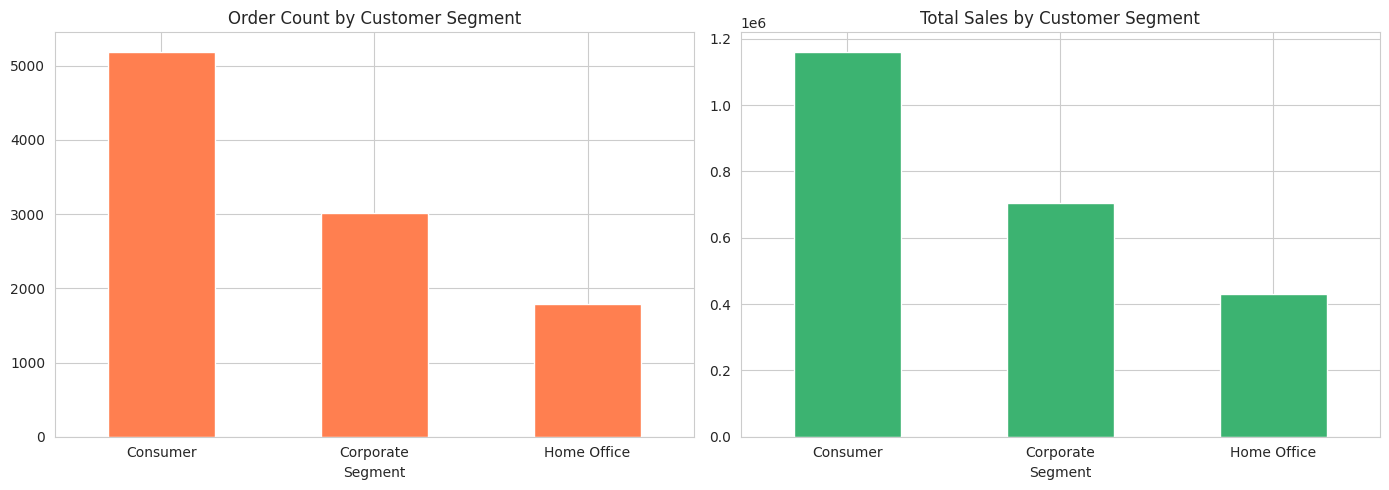

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

df['Segment'].value_counts().plot(kind='bar', ax=axes[0], color='coral')
axes[0].set_title('Order Count by Customer Segment')
axes[0].set_xlabel('Segment')
axes[0].tick_params(axis='x', rotation=0)

df.groupby('Segment')['Sales'].sum().plot(kind='bar', ax=axes[1], color='mediumseagreen')
axes[1].set_title('Total Sales by Customer Segment')
axes[1].set_xlabel('Segment')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()


**Observation:** *(e.g. "The Consumer segment drives the most orders and total sales,
while Home Office is the smallest — suggesting most revenue comes from individual
shoppers rather than businesses.")*

## 5. Product Analysis — Top 10 Best-Sellers & Revenue by Category

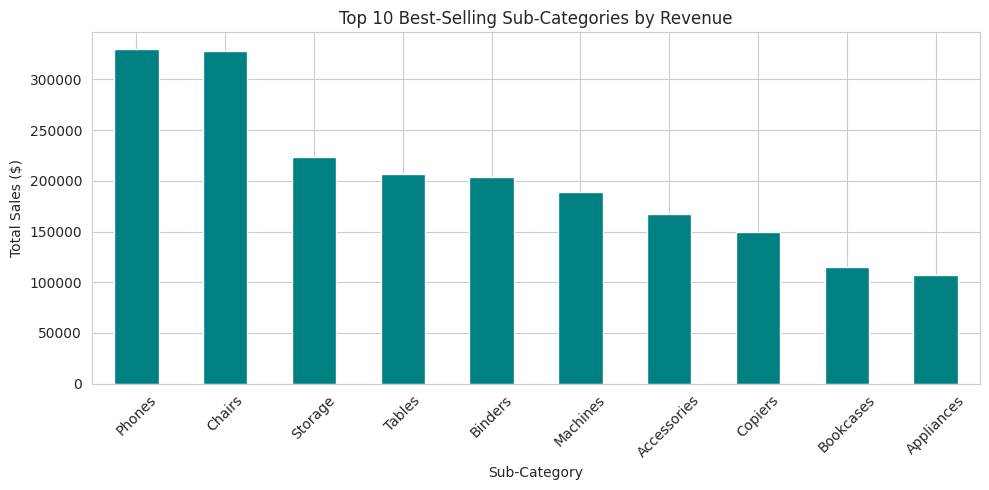

In [8]:
top_products = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_products.plot(kind='bar', color='teal')
plt.title('Top 10 Best-Selling Sub-Categories by Revenue')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


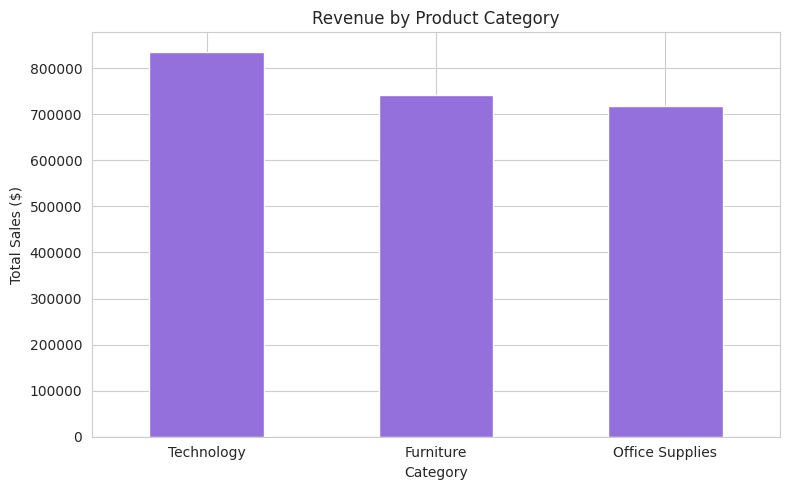

In [9]:
category_revenue = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
category_revenue.plot(kind='bar', color='mediumpurple')
plt.title('Revenue by Product Category')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


**Observation:** *(e.g. "Technology generates the highest revenue per category.
Within sub-categories, Phones and Chairs are the strongest sellers, while some
sub-categories may show high sales but low profit — worth cross-checking.")*

## 6. Correlation Heatmap

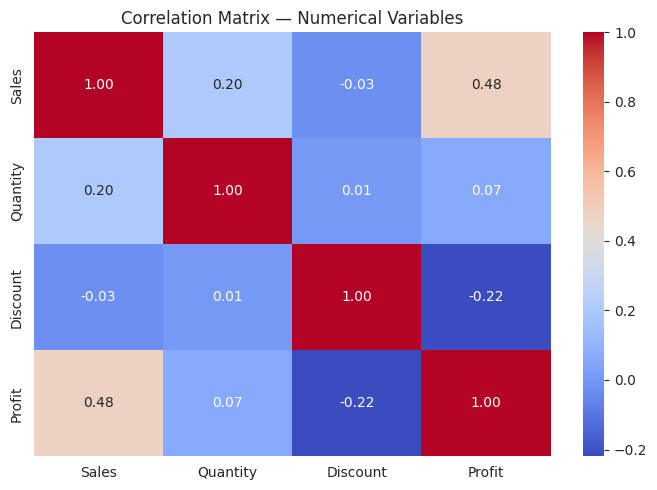

In [10]:
numeric_cols = df.select_dtypes(include='number').drop(columns=['Postal Code'])
corr = numeric_cols.corr()

plt.figure(figsize=(7,5))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix — Numerical Variables')
plt.tight_layout()
plt.show()


**Observation:** *(e.g. "Discount shows a negative correlation with Profit — as
discount percentage increases, profit tends to decrease, which makes intuitive sense.
Sales and Quantity show a moderate positive correlation.")*

## 7. Additional Visualisation — Discount vs Profit by Category (non-obvious insight)

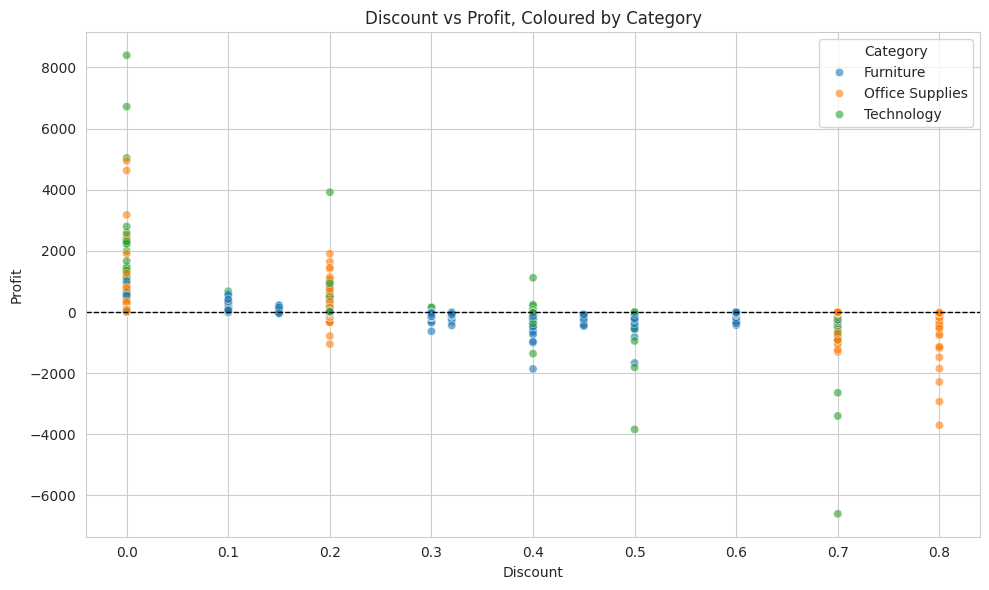

In [11]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Discount', y='Profit', hue='Category', alpha=0.6)
plt.title('Discount vs Profit, Coloured by Category')
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.tight_layout()
plt.show()


**Observation:** *(e.g. "Once discounts exceed roughly 20%, profit turns negative
for most categories — Furniture appears especially sensitive to discounting, going
into loss territory even at moderate discount levels.")*

## 8. Conclusion — Actionable Business Recommendations

*(Fill in after reviewing the charts above on your real output.)*

1. **Recommendation 1:** ...
2. **Recommendation 2:** ...
3. **Recommendation 3:** ...
